# Projet Python — Analyse des données AfriMarket
### Data Analyst : analyse stratégique du e-commerce panafricain AfriMarket

**Objectif** : auditer, nettoyer et analyser 6 mois d'activité commerciale d'AfriMarket
(4 catégories, 8 villes d'Afrique francophone) afin de fournir à la direction des
recommandations business actionnables.

**Sommaire**
1. Audit & compréhension des données
2. Data Cleaning
3. Feature Engineering
4. Analyses (performance globale, catégorie, géographie, marketing, clients)
5. Conclusion & recommandations stratégiques


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import json

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


## 1. Audit & compréhension des données

On charge le fichier brut fourni (`afrimarket_dataset_senior.csv`) et on examine sa
structure, ses types, ses valeurs manquantes, ses doublons et ses valeurs aberrantes
avant toute transformation.

In [2]:
df_raw = pd.read_csv('../data/afrimarket_dataset_senior.csv')
print('Dimensions :', df_raw.shape)
df_raw.head()

Dimensions : (10100, 14)


,id_commande,date_commande,id_client,ville,categorie,nom_produit,prix_unitaire,quantite,remise,cout_livraison,methode_paiement,canal_marketing,cout_marketing,statut_commande
0,CMD100000,2025-12-11,C0379,Brazzaville,Mode,Produit_Mode_9,49.72,3,0.07,2.45,Mobile Money,Email,1.00,Livrée
1,CMD100001,2025-07-27,C1827,Libreville,Beauté,Produit_Beauté_3,37.18,2,0.10,6.89,Paiement à la livraison,Instagram Ads,8.04,Livrée
2,CMD100002,2025-07-08,C0119,Abidjan,electronique,Produit_Électronique_36,315.60,0,0.04,5.60,Carte,Google Ads,7.30,Livrée
3,CMD100003,2025-08-20,C1436,Libreville,electronique,Produit_Électronique_29,143.25,0,0.03,5.96,Mobile Money,Google Ads,5.20,Livrée
4,CMD100004,2025-11-28,C0003,Libreville,Électronique,Produit_Électronique_45,498.71,2,0.02,5.16,Mobile Money,Email,0.55,Livrée


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 10100 entries, 0 to 10099
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_commande       10100 non-null  str    
 1   date_commande     10100 non-null  str    
 2   id_client         10100 non-null  str    
 3   ville             10100 non-null  str    
 4   categorie         10100 non-null  str    
 5   nom_produit       10100 non-null  str    
 6   prix_unitaire     10100 non-null  float64
 7   quantite          10100 non-null  int64  
 8   remise            10100 non-null  float64
 9   cout_livraison    10100 non-null  float64
 10  methode_paiement  10100 non-null  str    
 11  canal_marketing   10100 non-null  str    
 12  cout_marketing    10100 non-null  float64
 13  statut_commande   10100 non-null  str    
dtypes: float64(4), int64(1), str(9)
memory usage: 1.9 MB


In [4]:
print('Valeurs manquantes par colonne :')
print(df_raw.isnull().sum())
print()
print('Doublons stricts (toutes colonnes identiques) :', df_raw.duplicated().sum())


Valeurs manquantes par colonne :
id_commande         0
date_commande       0
id_client           0
ville               0
categorie           0
nom_produit         0
prix_unitaire       0
quantite            0
remise              0
cout_livraison      0
methode_paiement    0
canal_marketing     0
cout_marketing      0
statut_commande     0
dtype: int64

Doublons stricts (toutes colonnes identiques) : 100


In [5]:
print('Villes (brut) :', sorted(df_raw['ville'].unique()))
print()
print('Catégories (brut) :', sorted(df_raw['categorie'].unique()))
print()
print('Statuts (brut) :')
print(df_raw['statut_commande'].value_counts())

Villes (brut) : ['Abidjan', 'Brazzaville', 'Cotonou', 'Dakar', 'Douala', 'Kinshasa', 'Kinshassa', 'Libreville', 'Lomé']

Catégories (brut) : ['Beauté', 'Maison', 'Mode', 'electronique', 'Électronique']

Statuts (brut) :
statut_commande
Livrée       9080
retournée     826
Annulée       194
Name: count, dtype: int64


**Problèmes détectés :**
- `ville` : `Kinshassa` est une faute de frappe de `Kinshasa` (confirmé : un même client
  commande vers plusieurs villes, donc `ville` est un attribut de commande, pas de client —
  la variante est bien une erreur de saisie, pas une vraie seconde ville).
- `categorie` : la valeur `electronique` (minuscule, sans accent) n'est **pas** une simple
  variante de casse de `Électronique`. En croisant avec le préfixe de `nom_produit`
  (`Produit_<Catégorie>_NN`, fiable à 100 %), on constate que ces lignes couvrent en réalité
  les 4 catégories : la colonne `categorie` brute est corrompue pour ~6 % des lignes. On
  reconstruit donc `categorie` depuis `nom_produit`.
- `statut_commande` : casse non uniforme (`Livrée` / `retournée` / `Annulée`).
- `prix_unitaire` : 632 valeurs ≤ 0, dont **610 valeurs sentinelles exactement égales à
  -50.00** (marqueur d'erreur/valeur manquante) et 22 valeurs négatives isolées
  (erreur de signe probable).
- `remise` : 614 valeurs valent exactement **-0.10** (hors de la plage normale 0–0.30) —
  également une erreur de signe.
- `quantite` : 608 lignes à 0 — incohérent pour une commande livrée/retournée/annulée avec
  un prix renseigné.
- **100 lignes strictement dupliquées** (mêmes `id_commande` et mêmes valeurs partout).

Le détail chiffré est repris dans `rapport/audit_report.txt`.

## 2. Data Cleaning

Chaque problème identifié est corrigé avec une règle explicite et traçable. Le résultat
est sauvegardé dans `df_clean`.

In [6]:
df = df_raw.copy()
n_raw = len(df)

# --- Doublons stricts ---
n_dup = df.duplicated().sum()
df = df.drop_duplicates(keep='first').reset_index(drop=True)
print(f'{n_dup} doublons stricts supprimés -> {len(df)} lignes')

100 doublons stricts supprimés -> 10000 lignes


In [7]:
# --- Dates ---
df['date_commande'] = pd.to_datetime(df['date_commande'], errors='coerce')
print('Dates non converties :', df['date_commande'].isna().sum())
print('Période couverte :', df['date_commande'].min().date(), '->', df['date_commande'].max().date())

Dates non converties : 0
Période couverte : 2025-07-01 -> 2025-12-31


In [8]:
# --- Villes mal orthographiées ---
n_fix = (df['ville'] == 'Kinshassa').sum()
df['ville'] = df['ville'].replace({'Kinshassa': 'Kinshasa'})
print(f'{n_fix} lignes Kinshassa -> Kinshasa corrigées')
print(sorted(df['ville'].unique()))

600 lignes Kinshassa -> Kinshasa corrigées
['Abidjan', 'Brazzaville', 'Cotonou', 'Dakar', 'Douala', 'Kinshasa', 'Libreville', 'Lomé']


In [9]:
# --- Catégorie reconstruite depuis nom_produit (prefixe 100% fiable) ---
prefix = df['nom_produit'].str.extract(r'^Produit_([^_]+)_')[0]
n_incoherent = (df['categorie'].str.lower() != prefix.str.lower()).sum()
df['categorie'] = prefix
print(f'{n_incoherent} lignes avaient une catégorie brute incohérente')
print(sorted(df['categorie'].unique()))

600 lignes avaient une catégorie brute incohérente
['Beauté', 'Maison', 'Mode', 'Électronique']


In [10]:
# --- Uniformisation des statuts ---
df['statut_commande'] = df['statut_commande'].str.strip().str.lower().str.capitalize()
print(df['statut_commande'].value_counts())

statut_commande
Livrée       8991
Retournée     816
Annulée       193
Name: count, dtype: int64


In [11]:
# --- Prix aberrants ---
n_sentinel = (df['prix_unitaire'] == -50.00).sum()
n_other_neg = ((df['prix_unitaire'] < 0) & (df['prix_unitaire'] != -50.00)).sum()

mask_other_neg = (df['prix_unitaire'] < 0) & (df['prix_unitaire'] != -50.00)
df.loc[mask_other_neg, 'prix_unitaire'] = df.loc[mask_other_neg, 'prix_unitaire'].abs()

median_price = df.loc[df['prix_unitaire'] > 0].groupby('nom_produit')['prix_unitaire'].median()
mask_sentinel = df['prix_unitaire'] == -50.00
df.loc[mask_sentinel, 'prix_unitaire'] = df.loc[mask_sentinel, 'nom_produit'].map(median_price)

print(f'{n_sentinel} valeurs sentinelles (-50.00) imputées par la médiane du produit')
print(f'{n_other_neg} valeurs négatives isolées corrigées (valeur absolue)')
print('Prix <= 0 restants :', (df['prix_unitaire'] <= 0).sum())

600 valeurs sentinelles (-50.00) imputées par la médiane du produit
22 valeurs négatives isolées corrigées (valeur absolue)
Prix <= 0 restants : 0


In [12]:
# --- Remises négatives ---
n_remise_neg = (df['remise'] < 0).sum()
df['remise'] = df['remise'].abs()
print(f'{n_remise_neg} remises négatives corrigées (valeur absolue)')
print('Plage remise :', df['remise'].min(), '->', df['remise'].max())

600 remises négatives corrigées (valeur absolue)
Plage remise : 0.0 -> 0.3


In [13]:
# --- Quantités nulles : incohérentes, lignes supprimées ---
n_qty_zero = (df['quantite'] == 0).sum()
df = df[df['quantite'] > 0].reset_index(drop=True)
print(f'{n_qty_zero} lignes quantite=0 supprimées')
print(f'Lignes finales : {len(df)} (perte totale {n_raw - len(df)} lignes, {100*(n_raw-len(df))/n_raw:.1f}%)')

df_clean = df.copy()
df_clean.to_csv('../data/df_clean.csv', index=False)

600 lignes quantite=0 supprimées
Lignes finales : 9400 (perte totale 700 lignes, 6.9%)


## 3. Feature Engineering

> **Hypothèse métier documentée** : le dataset ne fournit pas le coût d'achat produit
> (COGS). La marge brute est donc **estimée** via un taux de marge par catégorie
> (hypothèse standard e-commerce, à valider avec la Finance) :
> Électronique 15 %, Mode 45 %, Beauté 55 %, Maison 35 %.
>
> Le **profit net** applique une logique métier : une commande *Annulée* n'a jamais été
> expédiée (perte du coût marketing engagé uniquement) ; une commande *Retournée* a généré
> des coûts logistique et marketing non récupérables mais aucune marge (perte de la marge).

In [14]:
TAUX_MARGE = {'Électronique': 0.15, 'Mode': 0.45, 'Beauté': 0.55, 'Maison': 0.35}

df['chiffre_affaires'] = df['prix_unitaire'] * df['quantite'] * (1 - df['remise'])
df['taux_marge'] = df['categorie'].map(TAUX_MARGE)
df['marge_brute'] = df['chiffre_affaires'] * df['taux_marge']

df['profit_net'] = np.select(
    [df['statut_commande'] == 'Annulée', df['statut_commande'] == 'Retournée'],
    [-df['cout_marketing'], -df['cout_livraison'] - df['cout_marketing']],
    default=df['marge_brute'] - df['cout_livraison'] - df['cout_marketing'],
)

df['mois'] = df['date_commande'].dt.to_period('M').astype(str)
df['indicateur_retour'] = (df['statut_commande'] == 'Retournée').astype(int)
df['indicateur_annulation'] = (df['statut_commande'] == 'Annulée').astype(int)
df['nombre_commandes_par_client'] = df.groupby('id_client')['id_commande'].transform('count')

ca_realise_ligne = df['chiffre_affaires'].where(df['statut_commande'] != 'Annulée', 0)
df['valeur_vie_client'] = df.assign(_ca=ca_realise_ligne).groupby('id_client')['_ca'].transform('sum')

df.to_csv('../data/df_features.csv', index=False)
df[['chiffre_affaires','marge_brute','profit_net','mois','indicateur_retour',
    'nombre_commandes_par_client','valeur_vie_client']].head()

,chiffre_affaires,marge_brute,profit_net,mois,indicateur_retour,nombre_commandes_par_client,valeur_vie_client
0,138.72,62.42,58.97,2025-12,0,25,"9,105.69"
1,66.92,36.81,21.88,2025-07,0,4,562.86
2,977.47,146.62,140.91,2025-11,0,26,"9,516.10"
3,192.16,67.26,53.18,2025-10,0,17,"4,690.20"
4,62.21,27.99,15.17,2025-07,0,16,"3,491.20"


## 4. Analyses

### 4.1 Performance globale

In [15]:
ca_total = df.loc[df['statut_commande'] != 'Annulée', 'chiffre_affaires'].sum()
profit_net_total = df['profit_net'].sum()
n_valides = (df['statut_commande'] != 'Annulée').sum()
panier_moyen = df.loc[df['statut_commande'] != 'Annulée', 'chiffre_affaires'].sum() / n_valides
taux_annulation = (df['statut_commande'] == 'Annulée').mean() * 100
taux_retour = (df['statut_commande'] == 'Retournée').mean() * 100

print(f'CA total               : {ca_total:,.0f} $')
print(f'Profit net estimé       : {profit_net_total:,.0f} $')
print(f'Panier moyen            : {panier_moyen:,.2f} $')
print(f"Taux d'annulation       : {taux_annulation:.2f} %")
print(f'Taux de retour          : {taux_retour:.2f} %')

CA total               : 2,496,745 $
Profit net estimé       : 363,340 $
Panier moyen            : 270.88 $
Taux d'annulation       : 1.95 %
Taux de retour          : 8.14 %


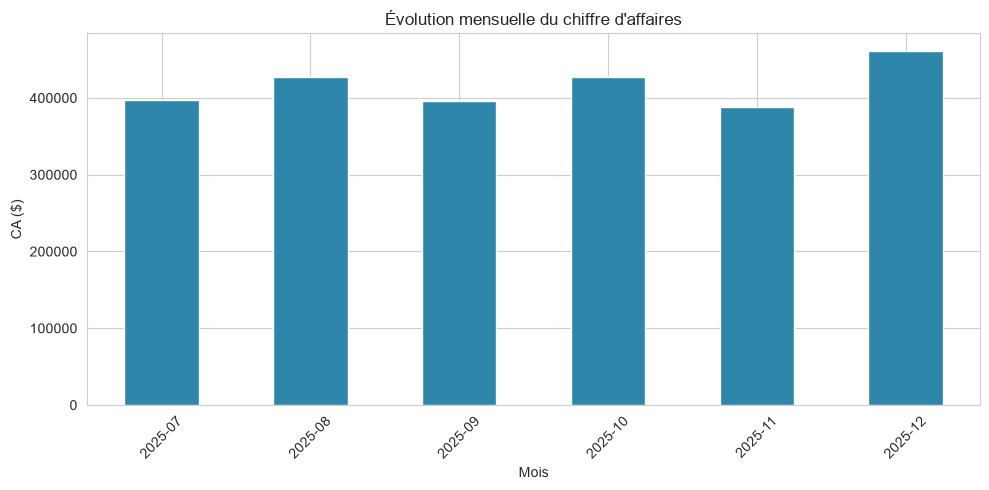

In [16]:
ca_mensuel = df[df['statut_commande'] != 'Annulée'].groupby('mois')['chiffre_affaires'].sum()
fig, ax = plt.subplots()
ca_mensuel.plot(kind='bar', ax=ax, color='#2E86AB')
ax.set_title("Évolution mensuelle du chiffre d'affaires")
ax.set_ylabel('CA ($)')
ax.set_xlabel('Mois')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.2 Analyse par catégorie

In [17]:
cat_stats = df.groupby('categorie').agg(
    ca=('chiffre_affaires', lambda s: s[df.loc[s.index,'statut_commande']!='Annulée'].sum()),
    marge=('marge_brute', lambda s: s[df.loc[s.index,'statut_commande']!='Annulée'].sum()),
    profit_net=('profit_net','sum'),
    nb_commandes=('id_commande','count'),
    taux_retour=('indicateur_retour','mean'),
).sort_values('ca', ascending=False)
cat_stats['taux_retour'] = (cat_stats['taux_retour']*100).round(2)
cat_stats

,ca,marge,profit_net,nb_commandes,taux_retour
categorie,,,,,
Électronique,"1,823,431.88","273,514.78","197,176.31",2597,15.33
Maison,"395,738.73","138,508.56","106,139.43",1916,4.91
Mode,"196,058.02","88,226.11","41,726.08",3000,7.33
Beauté,"81,516.64","44,834.15","18,298.38",1887,2.81


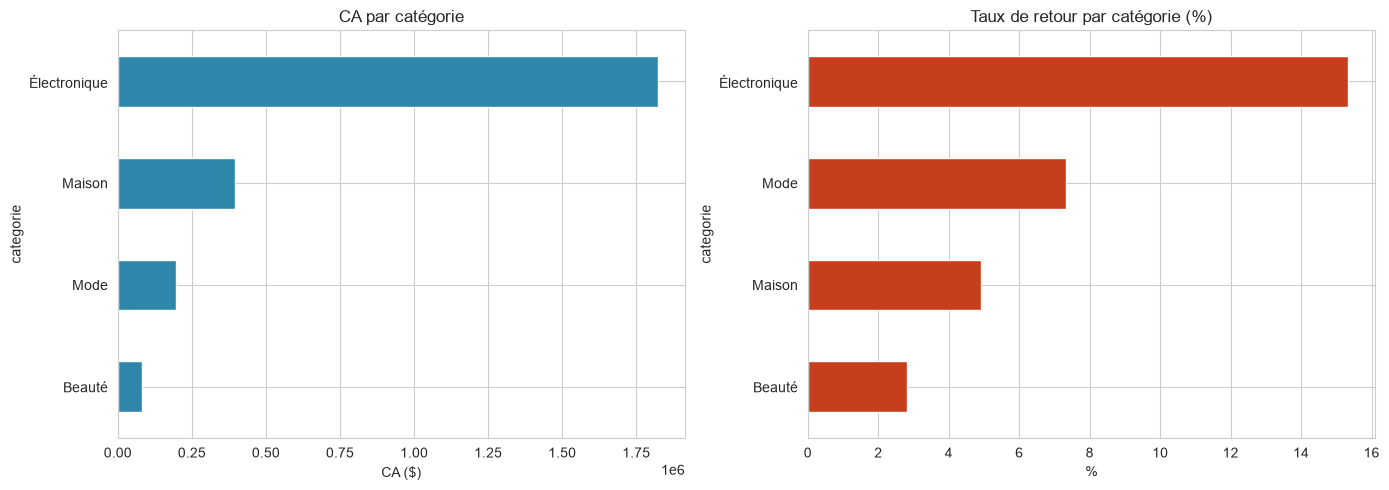

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
cat_stats['ca'].sort_values().plot(kind='barh', ax=axes[0], color='#2E86AB')
axes[0].set_title("CA par catégorie")
axes[0].set_xlabel('CA ($)')

cat_stats['taux_retour'].sort_values().plot(kind='barh', ax=axes[1], color='#C73E1D')
axes[1].set_title('Taux de retour par catégorie (%)')
axes[1].set_xlabel('%')
plt.tight_layout()
plt.show()

In [19]:
evo_cat = df[df['statut_commande']!='Annulée'].groupby(['mois','categorie'])['chiffre_affaires'].sum().reset_index()
fig = px.line(evo_cat, x='mois', y='chiffre_affaires', color='categorie',
              title="Évolution mensuelle du CA par catégorie", markers=True)
fig.show()

**Question stratégique — Quelle catégorie doit être priorisée ou optimisée ?**

`Électronique` génère à elle seule **73 % du CA total** (1,82 M$) et reste stable
mois après mois : c'est la catégorie à **prioriser** (volume, budget marketing,
disponibilité stock). Mais elle affiche aussi le **taux de retour le plus élevé (15,3 %)**,
presque le double de la moyenne globale (8,1 %) : c'est aussi la catégorie à **optimiser
en priorité** (qualité produit, fiche produit, SAV) car chaque point de retour gagné sur
Électronique a un impact financier bien supérieur à un gain identique sur les autres
catégories.

### 4.3 Analyse géographique

In [20]:
ville_stats = df.groupby('ville').agg(
    ca=('chiffre_affaires', lambda s: s[df.loc[s.index,'statut_commande']!='Annulée'].sum()),
    profit_net=('profit_net','sum'),
    taux_annulation=('indicateur_annulation','mean'),
    nb_commandes=('id_commande','count'),
).sort_values('ca', ascending=False)
ville_stats['taux_annulation'] = (ville_stats['taux_annulation']*100).round(2)

ca_mensuel_ville = df[df['statut_commande']!='Annulée'].groupby(['mois','ville'])['chiffre_affaires'].sum().reset_index()
piv = ca_mensuel_ville.pivot(index='ville', columns='mois', values='chiffre_affaires').fillna(0)
mois_tri = sorted(df['mois'].unique())
croissance = ((piv[mois_tri[-1]] - piv[mois_tri[0]]) / piv[mois_tri[0]] * 100).round(2)
ville_stats['croissance_juil_dec_pct'] = ville_stats.index.map(croissance)
ville_stats

,ca,profit_net,taux_annulation,nb_commandes,croissance_juil_dec_pct
ville,,,,,
Kinshasa,"752,891.33","109,682.80",0.26,2724,19.97
Abidjan,"498,115.56","71,353.57",0.00,1756,20.28
Dakar,"346,857.96","51,077.89",0.00,1346,-11.54
Douala,"327,898.83","47,562.73",12.92,1362,76.39
Lomé,"183,750.59","27,701.63",0.00,682,11.23
Cotonou,"157,958.74","24,274.01",0.00,631,4.74
Libreville,"123,331.56","16,537.38",0.00,467,-46.22
Brazzaville,"105,940.69","15,150.20",0.00,432,57.52


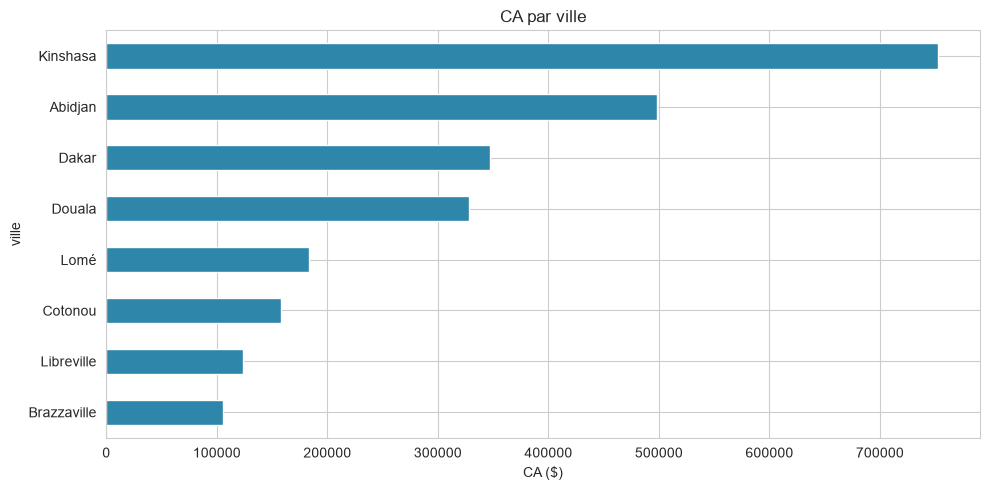

In [21]:
fig, ax = plt.subplots()
ville_stats['ca'].sort_values().plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title('CA par ville')
ax.set_xlabel('CA ($)')
plt.tight_layout()
plt.show()

In [22]:
fig = px.scatter(ville_stats.reset_index(), x='taux_annulation', y='croissance_juil_dec_pct',
                  size='ca', color='ville', text='ville',
                  title="Croissance vs Taux d'annulation par ville (taille = CA)",
                  labels={'taux_annulation':"Taux d'annulation (%)", 'croissance_juil_dec_pct':'Croissance juil.->déc. (%)'})
fig.update_traces(textposition='top center')
fig.show()

**Question stratégique — Où devons-nous investir davantage ?**

`Kinshasa` reste le marché n°1 (CA le plus élevé, annulations quasi nulles) : à
**consolider**. `Douala` est le marché le plus intéressant pour un **investissement
supplémentaire** : sa croissance juillet→décembre est la plus forte (+76 %) mais son
taux d'annulation (12,9 %) est très supérieur aux autres villes (0 % ailleurs) — un
problème opérationnel local (paiement, livraison) freine probablement une croissance
qui serait sinon la meilleure du réseau. `Libreville` recule fortement (-46 %) et mérite
un diagnostic avant d'y renforcer le budget.

### 4.4 Analyse marketing

In [23]:
mkt_stats = df.groupby('canal_marketing').agg(
    ca=('chiffre_affaires', lambda s: s[df.loc[s.index,'statut_commande']!='Annulée'].sum()),
    cout_marketing_total=('cout_marketing','sum'),
    nb_commandes=('id_commande','count'),
)
mkt_stats['roi'] = (mkt_stats['ca'] - mkt_stats['cout_marketing_total']) / mkt_stats['cout_marketing_total']

retention = {}
for canal, g in df.groupby('canal_marketing'):
    nb = g.groupby('id_client')['id_commande'].count()
    retention[canal] = (nb > 1).mean() * 100
mkt_stats['taux_retention_pct'] = pd.Series(retention)
mkt_stats = mkt_stats.sort_values('roi', ascending=False)
mkt_stats

,ca,cout_marketing_total,nb_commandes,roi,taux_retention_pct
canal_marketing,,,,,
Email,"527,688.32","2,349.15",1894,223.63,46.29
Google Ads,"663,081.95","13,158.93",2393,49.39,50.25
Instagram Ads,"946,400.80","37,637.07",3765,24.15,54.19
Influenceur,"359,574.21","16,359.59",1348,20.98,42.38


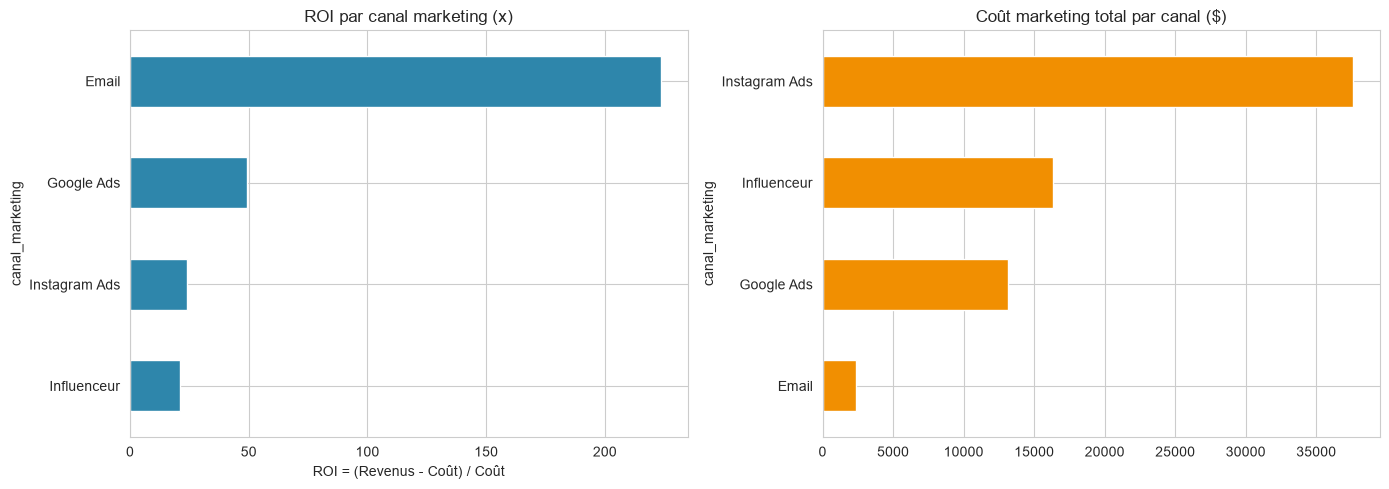

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
mkt_stats['roi'].sort_values().plot(kind='barh', ax=axes[0], color='#2E86AB')
axes[0].set_title('ROI par canal marketing (x)')
axes[0].set_xlabel('ROI = (Revenus - Coût) / Coût')

mkt_stats['cout_marketing_total'].sort_values().plot(kind='barh', ax=axes[1], color='#F18F01')
axes[1].set_title('Coût marketing total par canal ($)')
plt.tight_layout()
plt.show()

**Note méthodologique** : le ROI (`(Revenus - Coût marketing) / Coût marketing`) est ici
calculé en attribuant 100 % du CA de la commande au canal marketing associé, alors que
`cout_marketing` ne représente qu'un petit coût variable par commande (pas un budget de
campagne). Les valeurs de ROI sont donc très élevées en absolu ; c'est le
**classement relatif entre canaux** qui est actionnable, pas la valeur brute.

**Question stratégique — Quel canal mérite plus de budget ? Lequel réduire ?**

`Email` a de très loin le meilleur ROI et un coût total dérisoire (2 349 $ pour 527 688 $
de CA) : c'est un canal **sous-exploité** à renforcer (fréquence d'envoi, segmentation,
automatisation). `Instagram Ads` capte **60 % du budget marketing total** pour un ROI
très inférieur à Email et une rétention équivalente : à **optimiser/réduire** au profit
d'Email et de Google Ads. `Influenceur` cumule le plus mauvais ROI et la plus faible
rétention : c'est le canal à **réduire en priorité**.

### 4.5 Analyse clients

In [25]:
nb_clients_total = df['id_client'].nunique()
nb_par_client = df.groupby('id_client')['id_commande'].count()
pct_recurrents = (nb_par_client > 1).mean() * 100

ca_par_client = df[df['statut_commande']!='Annulée'].groupby('id_client')['chiffre_affaires'].sum().sort_values(ascending=False)
cum_pct_clients = np.arange(1, len(ca_par_client)+1) / len(ca_par_client) * 100
cum_pct_ca = ca_par_client.cumsum() / ca_par_client.sum() * 100
idx_80 = np.searchsorted(cum_pct_ca.values, 80)
pct_clients_pour_80pct_ca = cum_pct_clients[idx_80]

print(f'Nombre total de clients        : {nb_clients_total}')
print(f'% de clients récurrents        : {pct_recurrents:.2f} %')
print(f'% de clients générant 80% du CA: {pct_clients_pour_80pct_ca:.2f} %')

Nombre total de clients        : 1747
% de clients récurrents        : 74.01 %
% de clients générant 80% du CA: 31.83 %


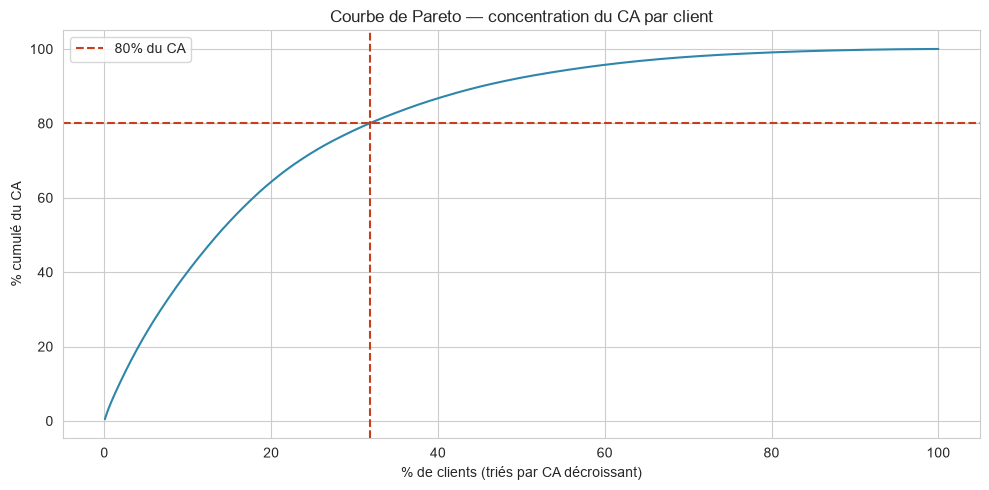

In [26]:
fig, ax = plt.subplots()
ax.plot(cum_pct_clients, cum_pct_ca, color='#2E86AB')
ax.axhline(80, color='#C73E1D', linestyle='--', label='80% du CA')
ax.axvline(pct_clients_pour_80pct_ca, color='#C73E1D', linestyle='--')
ax.set_xlabel('% de clients (triés par CA décroissant)')
ax.set_ylabel('% cumulé du CA')
ax.set_title('Courbe de Pareto — concentration du CA par client')
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
top10 = ca_par_client.head(10).reset_index()
top10.columns = ['id_client', 'ca_total']
top10

,id_client,ca_total
0,C0157,"11,553.74"
1,C0266,"10,673.23"
2,C0120,"9,542.21"
3,C0003,"9,516.10"
4,C0051,"9,442.25"
5,C0379,"9,105.69"
6,C0114,"8,915.44"
7,C0067,"8,476.41"
8,C0364,"8,252.47"
9,C0054,"8,080.54"


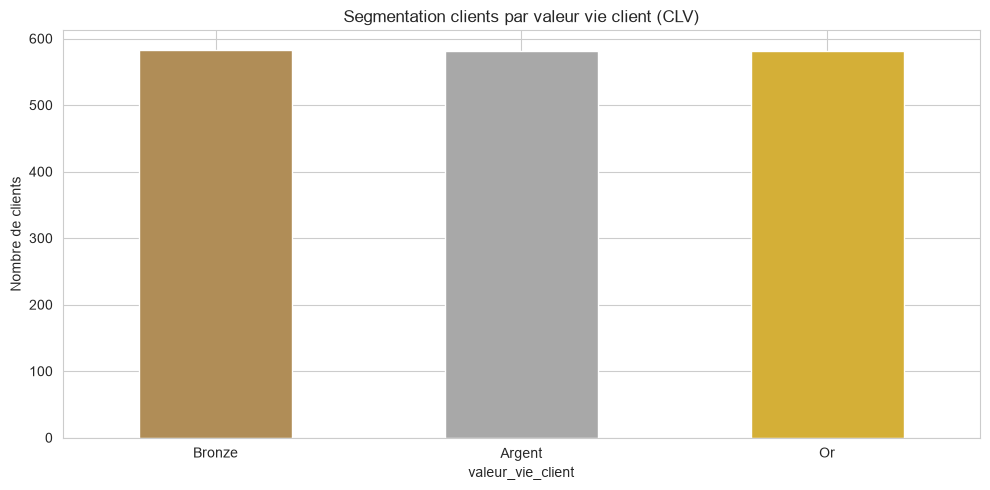

In [28]:
clv_par_client = df.groupby('id_client')['valeur_vie_client'].first()
segments = pd.qcut(clv_par_client, q=3, labels=['Bronze','Argent','Or'])
fig, ax = plt.subplots()
segments.value_counts().reindex(['Bronze','Argent','Or']).plot(kind='bar', ax=ax, color=['#B08D57','#A8A8A8','#D4AF37'])
ax.set_title('Segmentation clients par valeur vie client (CLV)')
ax.set_ylabel('Nombre de clients')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Question stratégique — Comment améliorer la rétention ?**

74 % des clients sont déjà récurrents (bon signal global), mais le CA reste concentré :
**32 % des clients génèrent 80 % du CA** (proche d'une dynamique Pareto). Le segment
« Or » (top tiers CLV) doit bénéficier d'un programme de fidélité dédié (accès anticipé,
livraison prioritaire) pour sécuriser ce socle de revenus, tandis que le segment
« Bronze », très nombreux mais à faible valeur, est le principal gisement de croissance
par la fréquence d'achat (relances ciblées, cross-sell) plutôt que par l'acquisition.

## 5. Conclusion & recommandations stratégiques

Voir le document **`rapport/Resume_Executif_AfriMarket.md`** pour le résumé exécutif complet
(5 pages), les 5 recommandations stratégiques priorisées et la conclusion orientée action.